In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
with open("dataset/kddcup.names",'r') as f:
    print(f.read())

back,buffer_overflow,ftp_write,guess_passwd,imap,ipsweep,land,loadmodule,multihop,neptune,nmap,normal,perl,phf,pod,portsweep,rootkit,satan,smurf,spy,teardrop,warezclient,warezmaster.
duration: continuous.
protocol_type: symbolic.
service: symbolic.
flag: symbolic.
src_bytes: continuous.
dst_bytes: continuous.
land: symbolic.
wrong_fragment: continuous.
urgent: continuous.
hot: continuous.
num_failed_logins: continuous.
logged_in: symbolic.
num_compromised: continuous.
root_shell: continuous.
su_attempted: continuous.
num_root: continuous.
num_file_creations: continuous.
num_shells: continuous.
num_access_files: continuous.
num_outbound_cmds: continuous.
is_host_login: symbolic.
is_guest_login: symbolic.
count: continuous.
srv_count: continuous.
serror_rate: continuous.
srv_serror_rate: continuous.
rerror_rate: continuous.
srv_rerror_rate: continuous.
same_srv_rate: continuous.
diff_srv_rate: continuous.
srv_diff_host_rate: continuous.
dst_host_count: continuous.
dst_host_srv_count: con

In [3]:
cols = """
  duration,
  protocol_type,
  service,
  flag,
  src_bytes,
  dst_bytes,
  land,
  wrong_fragment,
  urgent,
  hot,
  num_failed_logins,
  logged_in,
  num_compromised,
  root_shell,
  su_attempted,
  num_root,
  num_file_creations,
  num_shells,
  num_access_files,
  num_outbound_cmds,
  is_host_login,
  is_guest_login,
  count,
  srv_count,
  serror_rate,
  srv_serror_rate,
  rerror_rate,
  srv_rerror_rate,
  same_srv_rate,
  diff_srv_rate,
  srv_diff_host_rate,
  dst_host_count,
  dst_host_srv_count,
  dst_host_same_srv_rate,
  dst_host_diff_srv_rate,
  dst_host_same_src_port_rate,
  dst_host_srv_diff_host_rate,
  dst_host_serror_rate,
  dst_host_srv_serror_rate,
  dst_host_rerror_rate,
  dst_host_srv_rerror_rate
"""

columns = []
for c in cols.split(','):
    if (c.strip()):
       columns.append(c.strip())

columns.append('target')
print(columns, len(columns))

['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'target'] 42


In [4]:
with open("dataset/training_attack_types",'r') as f:
    print(f.read())

back dos
buffer_overflow u2r
ftp_write r2l
guess_passwd r2l
imap r2l
ipsweep probe
land dos
loadmodule u2r
multihop r2l
neptune dos
nmap probe
perl u2r
phf r2l
pod dos
portsweep probe
rootkit u2r
satan probe
smurf dos
spy r2l
teardrop dos
warezclient r2l
warezmaster r2l




In [5]:
attacks_types = {
  'normal': 'normal',
  'back': 'dos',
  'buffer_overflow': 'u2r',
  'ftp_write': 'r2l',
  'guess_passwd': 'r2l',
  'imap': 'r2l',
  'ipsweep': 'probe',
  'land': 'dos',
  'loadmodule': 'u2r',
  'multihop': 'r2l',
  'neptune': 'dos',
  'nmap': 'probe',
  'perl': 'u2r',
  'phf': 'r2l',
  'pod': 'dos',
  'portsweep': 'probe',
  'rootkit': 'u2r',
  'satan': 'probe',
  'smurf': 'dos',
  'spy': 'r2l',
  'teardrop': 'dos',
  'warezclient': 'r2l',
  'warezmaster': 'r2l'
}

In [6]:
df = pd.read_csv("dataset/kddcup.data_10_percent.gz", names=columns)

# Adding Attack Type column
df['Attack Type'] = df.target.apply(lambda r: attacks_types[r[:-1]])

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.,normal


In [7]:
df['duration'].unique()

array([   0,    1,   79, ..., 2695, 2751,  120], dtype=int64)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   protocol_type                494021 non-null  object 
 2   service                      494021 non-null  object 
 3   flag                         494021 non-null  object 
 4   src_bytes                    494021 non-null  int64  
 5   dst_bytes                    494021 non-null  int64  
 6   land                         494021 non-null  int64  
 7   wrong_fragment               494021 non-null  int64  
 8   urgent                       494021 non-null  int64  
 9   hot                          494021 non-null  int64  
 10  num_failed_logins            494021 non-null  int64  
 11  logged_in                    494021 non-null  int64  
 12  num_compromised              494021 non-null  int64  
 13 

In [9]:
df.shape

(494021, 43)

In [10]:
df['target'].value_counts()

target
smurf.              280790
neptune.            107201
normal.              97278
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
imap.                   12
rootkit.                10
loadmodule.              9
ftp_write.               8
multihop.                7
phf.                     4
perl.                    3
spy.                     2
Name: count, dtype: int64

In [11]:
df['Attack Type'].value_counts()

Attack Type
dos       391458
normal     97278
probe       4107
r2l         1126
u2r           52
Name: count, dtype: int64

In [12]:
df.dtypes

duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [13]:
df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

<Axes: xlabel='protocol_type', ylabel='count'>

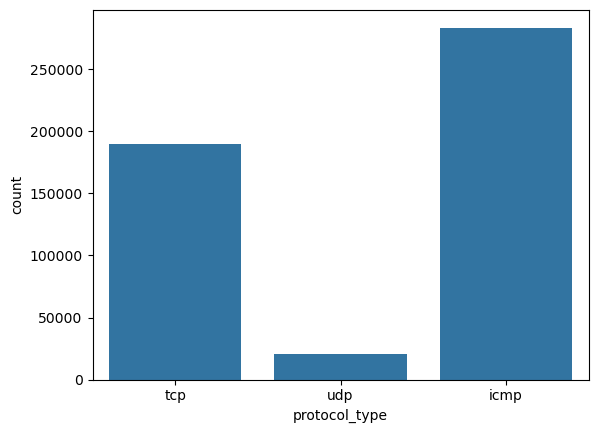

In [14]:

sns.countplot(x=df['protocol_type'], data=df)

<Axes: xlabel='flag', ylabel='count'>

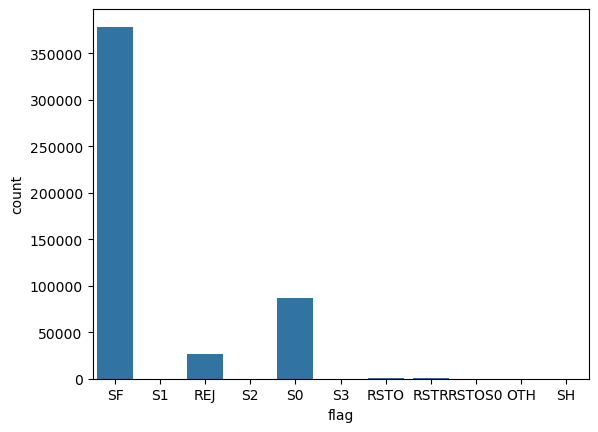

In [15]:

sns.countplot(x=df['flag'], data=df)

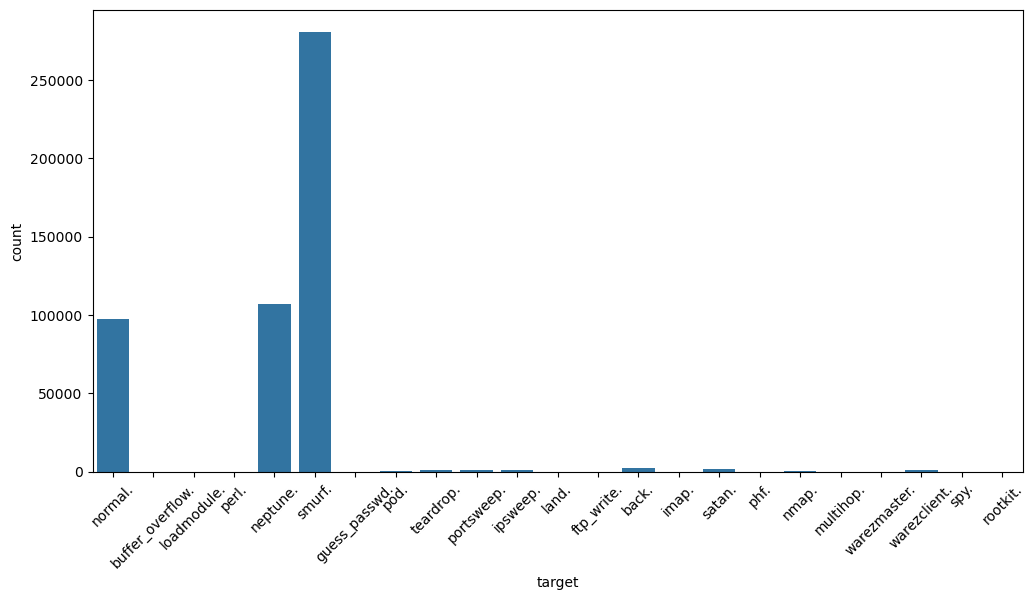

In [16]:

plt.figure(figsize=(12, 6))  # Adjust the width and height as needed
sns.countplot(x=df['target'], data=df)
plt.xticks(rotation=45)  # Rotate labels if too many categories
plt.show()

<Axes: xlabel='Attack Type', ylabel='count'>

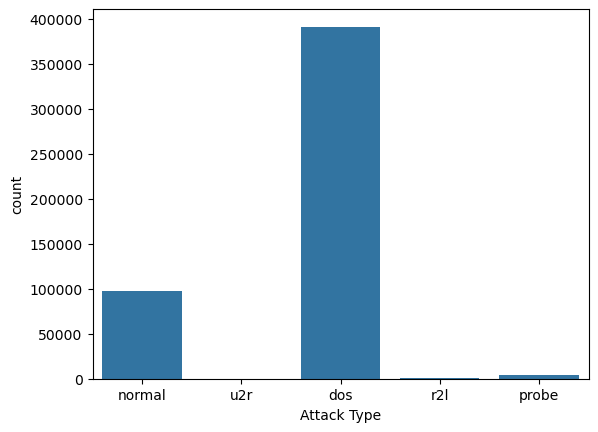

In [17]:

sns.countplot(x=df['Attack Type'], data=df)

In [18]:
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.11,0.00,0.00,0.00,0.0,0.0,normal.,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.05,0.00,0.00,0.00,0.0,0.0,normal.,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal.,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal.,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.00,0.00,0.00,0.0,0.0,normal.,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494016,0,tcp,http,SF,310,1881,0,0,0,0,...,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal.,normal
494017,0,tcp,http,SF,282,2286,0,0,0,0,...,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal.,normal
494018,0,tcp,http,SF,203,1200,0,0,0,0,...,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0,normal.,normal
494019,0,tcp,http,SF,291,1200,0,0,0,0,...,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0,normal.,normal


In [19]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'target', 'Attack Type'],
      dtype='object')

In [20]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.,normal


In [21]:
df.shape

(494021, 43)

In [22]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'target', 'Attack Type'],
      dtype='object')

In [23]:
df['protocol_type'].value_counts()

protocol_type
icmp    283602
tcp     190065
udp      20354
Name: count, dtype: int64

In [24]:
df.loc[df['Attack Type']=='normal','Attack Type'] = 'Normal Instances'
df.loc[df['Attack Type']=='u2r','Attack Type'] = 'U2R Attack'
df.loc[df['Attack Type']=='dos','Attack Type'] = 'dos Attack'
df.loc[df['Attack Type']=='r2l','Attack Type'] = 'r2l Attack'
df.loc[df['Attack Type']=='probe','Attack Type'] = 'probe Attack'

In [25]:
# protocol_type feature mapping
pmap = {
  'icmp': 0,
  'tcp': 1,
  'udp': 2
}

df['protocol_type'] = df['protocol_type'].map(pmap)

In [26]:
df['flag'].value_counts()

flag
SF        378440
S0         87007
REJ        26875
RSTR         903
RSTO         579
SH           107
S1            57
S2            24
RSTOS0        11
S3            10
OTH            8
Name: count, dtype: int64

In [27]:
# flag feature mapping
fmap = {
  'SF': 0,
  'S0': 1,
  'REJ': 2,
  'RSTR': 3,
  'RSTO': 4,
  'SH': 5,
  'S1': 6,
  'S2': 7,
  'RSTOS0': 8,
  'S3': 9,
  'OTH': 10
}

df['flag'] = df['flag'].map(fmap)

In [28]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type
0,0,1,http,0,181,5450,0,0,0,0,...,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.,Normal Instances
1,0,1,http,0,239,486,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.,Normal Instances
2,0,1,http,0,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,Normal Instances
3,0,1,http,0,219,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,Normal Instances
4,0,1,http,0,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.,Normal Instances


In [29]:
df.drop('service', axis=1, inplace=True)

In [30]:
df.shape

(494021, 42)

In [31]:
df.head()

,duration,protocol_type,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type
0,0,1,0,181,5450,0,0,0,0,0,...,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.,Normal Instances
1,0,1,0,239,486,0,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.,Normal Instances
2,0,1,0,235,1337,0,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,Normal Instances
3,0,1,0,219,1337,0,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,Normal Instances
4,0,1,0,217,2032,0,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.,Normal Instances


In [32]:
df['duration'].value_counts()

duration
0        481671
1          2476
2           870
3           625
5           554
          ...  
18185         1
4283          1
2154          1
1007          1
120           1
Name: count, Length: 2495, dtype: int64

In [33]:
df.dtypes

duration                         int64
protocol_type                    int64
flag                             int64
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate                float64
rerror_rate              

In [34]:
df['Attack Type'].unique()

array(['Normal Instances', 'U2R Attack', 'dos Attack', 'r2l Attack',
       'probe Attack'], dtype=object)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import pickle

In [36]:
X = df[['duration','protocol_type','flag','src_bytes','dst_bytes','count','srv_count','same_srv_rate','diff_srv_rate','dst_host_same_srv_rate','dst_host_srv_count','serror_rate','srv_serror_rate']]
Y = df['Attack Type']

In [37]:
X

,duration,protocol_type,flag,src_bytes,dst_bytes,count,srv_count,same_srv_rate,diff_srv_rate,dst_host_same_srv_rate,dst_host_srv_count,serror_rate,srv_serror_rate
0,0,1,0,181,5450,8,8,1.0,0.0,1.0,9,0.00,0.00
1,0,1,0,239,486,8,8,1.0,0.0,1.0,19,0.00,0.00
2,0,1,0,235,1337,8,8,1.0,0.0,1.0,29,0.00,0.00
3,0,1,0,219,1337,6,6,1.0,0.0,1.0,39,0.00,0.00
4,0,1,0,217,2032,6,6,1.0,0.0,1.0,49,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
494016,0,1,0,310,1881,4,5,1.0,0.0,1.0,255,0.00,0.00
494017,0,1,0,282,2286,6,6,1.0,0.0,1.0,255,0.00,0.00
494018,0,1,0,203,1200,6,18,1.0,0.0,1.0,255,0.17,0.11
494019,0,1,0,291,1200,6,12,1.0,0.0,1.0,255,0.00,0.00


In [38]:
Y

0         Normal Instances
1         Normal Instances
2         Normal Instances
3         Normal Instances
4         Normal Instances
                ...       
494016    Normal Instances
494017    Normal Instances
494018    Normal Instances
494019    Normal Instances
494020    Normal Instances
Name: Attack Type, Length: 494021, dtype: object

In [39]:
from imblearn.over_sampling import RandomOverSampler
ro=RandomOverSampler()
x_data,y_data=ro.fit_resample(X,Y)

In [40]:
from collections import Counter
print("Actual Data:",Counter(Y))

Actual Data: Counter({'dos Attack': 391458, 'Normal Instances': 97278, 'probe Attack': 4107, 'r2l Attack': 1126, 'U2R Attack': 52})


In [41]:
print("Artificial Data:",Counter(y_data))

Artificial Data: Counter({'Normal Instances': 391458, 'U2R Attack': 391458, 'dos Attack': 391458, 'r2l Attack': 391458, 'probe Attack': 391458})


In [42]:

X_train, X_test, Y_train, Y_test = train_test_split(x_data, y_data, test_size=0.33, random_state=42)
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(1311384, 13) (645906, 13)
(1311384,) (645906,)


In [43]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=500, 
    learning_rate=0.1, 
    #loss_function='CrossEntropy'
)

In [44]:
cat.fit(X_train,Y_train)

0:	learn: 1.3065521	total: 4.69s	remaining: 39m 1s
1:	learn: 1.1014477	total: 6.26s	remaining: 25m 58s
2:	learn: 0.9523480	total: 8.03s	remaining: 22m 11s
3:	learn: 0.8348652	total: 9.68s	remaining: 19m 59s
4:	learn: 0.7423935	total: 11.4s	remaining: 18m 48s
5:	learn: 0.6623214	total: 13.6s	remaining: 18m 40s
6:	learn: 0.5985083	total: 15.5s	remaining: 18m 13s
7:	learn: 0.5392688	total: 17.4s	remaining: 17m 48s
8:	learn: 0.4903409	total: 19s	remaining: 17m 18s
9:	learn: 0.4489440	total: 20.8s	remaining: 16m 59s
10:	learn: 0.4139589	total: 22.4s	remaining: 16m 37s
11:	learn: 0.3801791	total: 24s	remaining: 16m 16s
12:	learn: 0.3526877	total: 25.3s	remaining: 15m 47s
13:	learn: 0.3268190	total: 26.8s	remaining: 15m 31s
14:	learn: 0.3022534	total: 28.2s	remaining: 15m 12s
15:	learn: 0.2822200	total: 29.4s	remaining: 14m 49s
16:	learn: 0.2628973	total: 30.8s	remaining: 14m 33s
17:	learn: 0.2464924	total: 32.2s	remaining: 14m 20s
18:	learn: 0.2325332	total: 33.3s	remaining: 14m 4s
19:	learn

In [45]:
cat.score(X_train,Y_train)

0.9998619778798582

In [46]:
from sklearn.metrics import accuracy_score
y_pred = cat.predict(X_test )
accuracy_score(y_pred,Y_test)

0.9997940876845857

In [47]:
import sklearn.metrics

In [48]:
print(sklearn.metrics.classification_report(Y_test, y_pred))

                  precision    recall  f1-score   support

Normal Instances       1.00      1.00      1.00    129395
      U2R Attack       1.00      1.00      1.00    128832
      dos Attack       1.00      1.00      1.00    129094
    probe Attack       1.00      1.00      1.00    129620
      r2l Attack       1.00      1.00      1.00    128965

        accuracy                           1.00    645906
       macro avg       1.00      1.00      1.00    645906
    weighted avg       1.00      1.00      1.00    645906



In [49]:
y_pred = cat.predict(X_test )
y_true=Y_test


from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_true,y_pred)
cm

array([[129328,     19,      4,     11,     33],
       [     0, 128832,      0,      0,      0],
       [     4,      0, 129071,     16,      3],
       [    43,      0,      0, 129577,      0],
       [     0,      0,      0,      0, 128965]], dtype=int64)

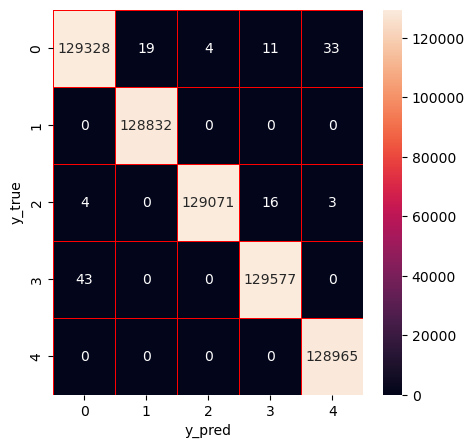

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [51]:
import pickle

pickle.dump(cat,open('catboost.pkl','wb'))
catboost = pickle.load(open('catboost.pkl','rb'))

In [52]:

from sklearn.tree import ExtraTreeClassifier

Models = ExtraTreeClassifier()

In [53]:
Models.fit(X_train,Y_train)

ExtraTreeClassifier()

In [54]:
Models.score(X_train,Y_train)

0.999965685108252

In [55]:
from sklearn.metrics import accuracy_score
y_pred = Models.predict(X_test )
accuracy_score(y_pred,Y_test)

0.9998885286713547

In [56]:
import sklearn.metrics

In [57]:
print(sklearn.metrics.classification_report(Y_test, y_pred))

                  precision    recall  f1-score   support

Normal Instances       1.00      1.00      1.00    129395
      U2R Attack       1.00      1.00      1.00    128832
      dos Attack       1.00      1.00      1.00    129094
    probe Attack       1.00      1.00      1.00    129620
      r2l Attack       1.00      1.00      1.00    128965

        accuracy                           1.00    645906
       macro avg       1.00      1.00      1.00    645906
    weighted avg       1.00      1.00      1.00    645906



In [58]:
y_pred = Models.predict(X_test )
y_true=Y_test


from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_true,y_pred)
cm

array([[129348,      0,      7,     23,     17],
       [     0, 128832,      0,      0,      0],
       [     7,      0, 129069,     16,      2],
       [     0,      0,      0, 129620,      0],
       [     0,      0,      0,      0, 128965]], dtype=int64)

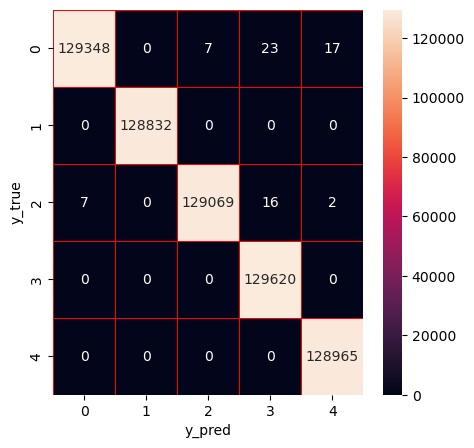

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [60]:
pickle.dump(Models,open('ExtraTreeClassifier.pkl','wb'))
ExtraTreeClassifier = pickle.load(open('ExtraTreeClassifier.pkl','rb'))

In [61]:
from sklearn.ensemble import GradientBoostingClassifier

In [62]:
gb = GradientBoostingClassifier(random_state=0)

In [63]:
gb.fit(X_train,Y_train)

GradientBoostingClassifier(random_state=0)

In [64]:
gb.score(X_train,Y_train)

0.9981630094617595

In [65]:
from sklearn.metrics import accuracy_score
y_pred = gb.predict(X_test )
accuracy_score(y_pred,Y_test)

0.9980987945614377

In [66]:
import sklearn.metrics

In [67]:
print(sklearn.metrics.classification_report(Y_test, y_pred))

                  precision    recall  f1-score   support

Normal Instances       1.00      0.99      1.00    129395
      U2R Attack       1.00      1.00      1.00    128832
      dos Attack       1.00      1.00      1.00    129094
    probe Attack       1.00      1.00      1.00    129620
      r2l Attack       1.00      1.00      1.00    128965

        accuracy                           1.00    645906
       macro avg       1.00      1.00      1.00    645906
    weighted avg       1.00      1.00      1.00    645906



In [68]:
y_pred = gb.predict(X_test )
y_true=Y_test


from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_true,y_pred)
cm

array([[128691,    175,      9,     93,    427],
       [     0, 128832,      0,      0,      0],
       [    60,      5, 128980,     41,      8],
       [   300,      0,      0, 129320,      0],
       [   110,      0,      0,      0, 128855]], dtype=int64)

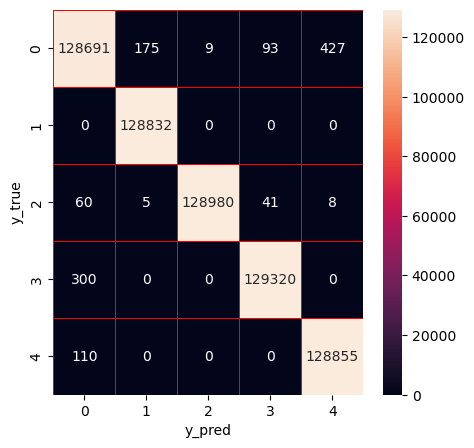

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [70]:
pickle.dump(gb,open('gbClassifier.pkl','wb'))
gbClassifier = pickle.load(open('gbClassifier.pkl','rb'))

In [74]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Binarize the output
classes = np.unique(Y_test)
Y_test_bin = label_binarize(Y_test, classes=classes)
n_classes = Y_test_bin.shape[1]


In [75]:
y_pred_proba_model1 = cat.predict_proba(X_test)
y_pred_proba_model2 = gb.predict_proba(X_test)
y_pred_proba_model3 = Models.predict_proba(X_test)


In [76]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[f"model1_{i}"], tpr[f"model1_{i}"], _ = roc_curve(Y_test_bin[:, i], y_pred_proba_model1[:, i])
    roc_auc[f"model1_{i}"] = auc(fpr[f"model1_{i}"], tpr[f"model1_{i}"])

    fpr[f"model2_{i}"], tpr[f"model2_{i}"], _ = roc_curve(Y_test_bin[:, i], y_pred_proba_model2[:, i])
    roc_auc[f"model2_{i}"] = auc(fpr[f"model2_{i}"], tpr[f"model2_{i}"])

    fpr[f"model3_{i}"], tpr[f"model3_{i}"], _ = roc_curve(Y_test_bin[:, i], y_pred_proba_model3[:, i])
    roc_auc[f"model3_{i}"] = auc(fpr[f"model3_{i}"], tpr[f"model3_{i}"])


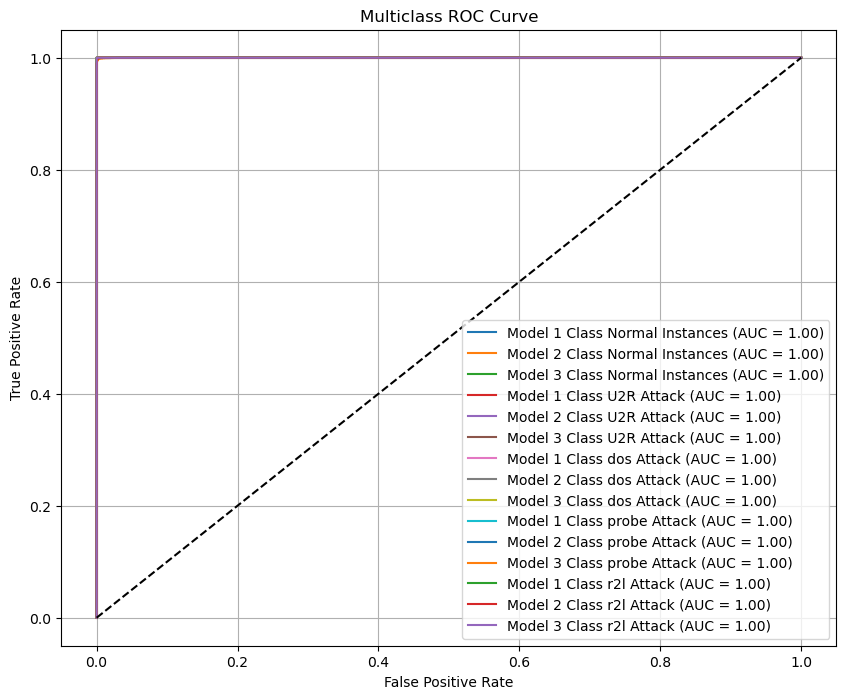

In [77]:
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[f"model1_{i}"], tpr[f"model1_{i}"], label=f'Model 1 Class {classes[i]} (AUC = {roc_auc[f"model1_{i}"]:.2f})')
    plt.plot(fpr[f"model2_{i}"], tpr[f"model2_{i}"], label=f'Model 2 Class {classes[i]} (AUC = {roc_auc[f"model2_{i}"]:.2f})')
    plt.plot(fpr[f"model3_{i}"], tpr[f"model3_{i}"], label=f'Model 3 Class {classes[i]} (AUC = {roc_auc[f"model3_{i}"]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
